Maria Navarro  
March 16, 2024  
Healthcare Data & Analytics Case Study: Insurance Claims Data & Analytics Cluster Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Read text files
inp = pd.read_csv('G:/My Drive/Spring 2024/Healthcare/Week4/VTINP16_upd/VTINP16_upd.txt', delimiter=',')  # Assuming comma-separated values
ed = pd.read_csv('G:/My Drive/Spring 2024/Healthcare/Week4/VTED16/vted16.txt', delimiter=',')
outp = pd.read_csv('G:/My Drive/Spring 2024/Healthcare/Week4/VTOUTP16/VTOUTP16.txt', delimiter=',')
rev = pd.read_csv('G:/My Drive/Spring 2024/Healthcare/Week4/VTREVCODE16/VTREVCODE16.txt', delimiter=',')

C:\Users\mfncn\AppData\Local\Temp\ipykernel_4560\4080399450.py:2: DtypeWarning: Columns (2,5,8,54,55,73,74,75,76,78) have mixed types. Specify dtype option on import or set low_memory=False.
  inp = pd.read_csv('G:/My Drive/Spring 2024/Healthcare/Week4/VTINP16_upd/VTINP16_upd.txt', delimiter=',')  # Assuming comma-separated values
C:\Users\mfncn\AppData\Local\Temp\ipykernel_4560\4080399450.py:3: DtypeWarning: Columns (2,5,8,54,55,56,57,69) have mixed types. Specify dtype option on import or set low_memory=False.
  ed = pd.read_csv('G:/My Drive/Spring 2024/Healthcare/Week4/VTED16/vted16.txt', delimiter=',')
C:\Users\mfncn\AppData\Local\Temp\ipykernel_4560\4080399450.py:4: DtypeWarning: Columns (2,5,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  outp = pd.read_csv('G:/My Drive/Spring 2024/Healthcare/Week4/VTOUTP16/VTOUTP16.txt', delimiter=',')
C:\Users\mfncn\AppData\Local\Temp\ipykernel_4560\4080399450.py:5: DtypeWarning: Columns (6,7,9) have mix

In [4]:
inp['DRG'].dtype
inp['DRG'].unique

<bound method Series.unique of 0        949
1        949
2        560
3        561
4        181
        ... 
53662    291
53663    781
53664    813
53665    189
53666     84
Name: DRG, Length: 53667, dtype: object>

In [4]:
#inp['DRG'] = inp['DRG'].astype(int)

In [4]:
inp['DRG'] = pd.to_numeric(inp['DRG'], errors='coerce')  # Convert invalid values to NaN
inp['DRG'] = inp['DRG'].fillna(0)  # Replace NaN with a default value
inp['DRG'] = inp['DRG'].astype(int)  # Convert to integer

In [5]:
# Filter your hospital admissions to only important DRGs between 20 and 977
inp1 = inp[(inp['DRG']>20) & (inp['DRG']<977)]

In [6]:
inp1['UNIQ'].nunique()
#rev['Uniq']

53283

In [7]:
len(inp1)

53283

In [9]:
rev['Uniq'].nunique()

1959739

In [10]:
len(rev)

7930298

In [8]:
# Left join
inp_rev = pd.merge(inp1, rev, left_on='UNIQ', right_on='Uniq', how='left')

In [12]:
len(inp_rev)

695797

In [13]:
inp_rev.columns

Index(['hnum2_x', 'ATYPE', 'asour', 'intage', 'TXTZIP', 'sex', 'dstat', 'PPAY',
       'CHRGS', 'DX1', 'DX2', 'DX3', 'DX4', 'DX5', 'DX6', 'DX7', 'DX8', 'DX9',
       'DX10', 'DX11', 'DX12', 'DX13', 'DX14', 'DX15', 'DX16', 'DX17', 'DX18',
       'DX19', 'DX20', 'PX1', 'PX2', 'PX3', 'PX4', 'PX5', 'PX6', 'PX7', 'PX8',
       'PX9', 'PX10', 'PX11', 'PX12', 'PX13', 'PX14', 'PX15', 'PX16', 'PX17',
       'PX18', 'PX19', 'PX20', 'ECODE1', 'ECODE2', 'ECODE3', 'hsa', 'pdays',
       'ccsdx', 'ccsdxgrp', 'CCSPX', 'CCSPXGRP', 'ccsppx', 'ccsppxgrp',
       'ccsproc_x', 'ccsprocgrp_x', 'DY', 'RECNO', 'BTYPE_x', 'ERFLAG', 'cah',
       'vtres', 'OBSFLAG', 'AFLAG', 'UNIQ', 'ADMID_QTR', 'DISCD_QTR_x',
       'CHRGS_HCIA', 'SCUD', 'DRG', 'MDC', 'sdf', 'GROUPER', 'dy', 'hnum2_y',
       'DISCD_QTR_y', 'BTYPE_y', 'Uniq', 'REVCODE', 'REVCHRGS', 'REVUNITS',
       'CPT', 'PCCR', 'PRIMARY_CPT', 'SFLAG', 'ccsproc_y', 'ccsprocgrp_y'],
      dtype='object')

In [9]:
# Convert REVCHRGS column to float
inp_rev['REVCHRGS'] = pd.to_numeric(inp_rev['REVCHRGS'], errors='coerce')  # Convert invalid values to NaN
inp_rev['REVCHRGS'] = inp_rev['REVCHRGS'].fillna(0)  # Replace NaN with a default value
inp_rev['REVCHRGS'] = inp_rev['REVCHRGS'].astype(float)

In [10]:
# In your Revenue file exclude the low dollar value services (less than $100)
inp_rev = inp_rev[inp_rev['REVCHRGS'] >= 100]

In [16]:
len(inp_rev)

553919

In [17]:
inp_rev['PCCR'].unique()

array([' ', '3390', '4100', '4700', '3630', '5000', '5100', '6000',
       '3280', '3650', '5600', '3560', '5200', '3700', '3260', '4900',
       '3230', '3420', '3180', '5500', '5530', '4000', '3800', '3900',
       '3070', '6100', '6201', '3140', '3540', '5800', '3120', '3030',
       '5700', '3320', '4800', '3430', '3040', '3370', '3450', '4200',
       '3240', '3440', '3220', '3190', '3620', '3290', '3340', '3350',
       '3050', '3380', '3480', '4600', '8600', '3550', '3360', '3640'],
      dtype=object)

In [11]:
# there are missing PCCR values, so we will drop them
len(inp_rev[inp_rev['PCCR'] ==' '])

74206

In [12]:
inp_rev = inp_rev[inp_rev['PCCR'] != ' ']

In [20]:
len(inp_rev)

479713

In [13]:
# Sum all the charges by the PCCR category
# Some hospital admissions may have multiple charges submitted from the same PCCR department so you want to add them all

inp_rev_by_pccr = inp_rev[['UNIQ', 'DRG', 'PCCR', 'REVCHRGS']].groupby(['UNIQ', 'DRG', 'PCCR']).sum('REVCHRGS').reset_index()

In [14]:
inp_rev_by_pccr.sort_values('REVCHRGS')

,UNIQ,DRG,PCCR,REVCHRGS
289240,1585388,560,3390,100.00
211523,1138909,791,3390,100.00
252565,1344349,330,3390,100.00
171221,943977,192,3390,100.00
258525,1345027,637,3390,100.00
...,...,...,...,...
330313,1824867,945,5600,341427.29
129279,709684,642,5600,406246.25
86240,459294,840,5600,427553.60
207596,1124888,847,5600,497096.89


In [15]:
inp_rev_by_pccr

,UNIQ,DRG,PCCR,REVCHRGS
0,254,949,3390,6786.00
1,254,949,3630,885.00
2,254,949,4100,3383.00
3,254,949,4700,1615.00
4,254,949,5000,8621.00
...,...,...,...,...
367434,1984564,84,3390,330.88
367435,1984564,84,4100,779.61
367436,1984564,84,4900,2741.51
367437,1984564,84,5600,148.95


In [16]:
# checking results
inp_rev_by_pccr['PCCR'].unique()

array(['3390', '3630', '4100', '4700', '5000', '5100', '6000', '3280',
       '3650', '5600', '3560', '5200', '3260', '3700', '4900', '3230',
       '3420', '3180', '3800', '4000', '5500', '5530', '3070', '3900',
       '6100', '6201', '3140', '3540', '5800', '3120', '3030', '5700',
       '3320', '3430', '4800', '3040', '3370', '3450', '4200', '3240',
       '3440', '3220', '3190', '3620', '3290', '3340', '3350', '3050',
       '3380', '3480', '4600', '8600', '3550', '3360', '3640'],
      dtype=object)

In [25]:
# checking results
inp_rev_by_pccr[(inp_rev_by_pccr['DRG']==21) & (inp_rev_by_pccr['PCCR']=='3230')]

,UNIQ,DRG,PCCR,REVCHRGS
237877,1220034,21,3230,11301.26
333481,1837122,21,3230,14659.12
333560,1837689,21,3230,25815.64
348101,1898897,21,3230,18336.27
357743,1948257,21,3230,22199.89


In [17]:
crosstab = inp_rev_by_pccr.pivot_table(index='DRG', columns='PCCR', values='REVCHRGS', aggfunc='mean')
crosstab.fillna(0, inplace=True)

In [27]:
crosstab

PCCR,3030,3040,3050,3070,3120,3140,3180,3190,3220,3230,...,5200,5500,5530,5600,5700,5800,6000,6100,6201,8600
DRG,,,,,,,,,,,,,,,,,,,,,
21,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,18462.436000,...,978.500000,7085.536000,22580.270000,14013.122000,0.00,0.00,0.0,3263.788000,0.00,0.0
22,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,5650.630000,...,0.000000,7261.395000,17200.255000,5793.075000,0.00,0.00,0.0,2984.330000,0.00,0.0
23,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,16825.415769,...,2273.382667,8392.076667,18614.876667,11467.082308,2613.30,0.00,0.0,5432.852400,0.00,0.0
24,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,10460.321429,...,1970.567500,8761.326250,20353.905000,4812.456250,0.00,0.00,0.0,4317.347500,0.00,0.0
25,0.0,0.0,0.0,0.0,0.0,4126.84,0.0,545.0,0.0,10254.480152,...,1146.528182,2110.928235,8161.737385,4970.941912,4442.24,0.00,194.0,3279.719535,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,0.0,0.0,0.0,0.0,0.0,0.00,284.5,0.0,0.0,6718.922500,...,1773.295000,237.495000,686.400000,1443.811429,0.00,0.00,0.0,5902.772353,387.75,0.0
970,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,4112.290000,...,0.000000,800.230000,983.380000,25789.360000,0.00,8433.48,0.0,3714.220000,0.00,0.0
974,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,8023.782500,...,3891.820000,165.832500,757.575000,26128.158000,0.00,0.00,0.0,2235.762500,0.00,0.0


In [498]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Read revcode file to extract REVCODE_DESC names
PCCR_names = pd.read_excel('G:/My Drive/Spring 2024/Advanced_Healthcare/Week1/REVCODE_FILE_LAYOUT_and_CODES.xls', sheet_name='PCCR')

In [19]:
# Convert PCCR to integers
PCCR_names['PCCR'] = PCCR_names['PCCR'].astype(str)

In [20]:
# Rename the cross tab column names
column_mapping_dict = dict(zip(PCCR_names['PCCR'], PCCR_names['PCCR_NAME']))

# Rename columns based on mapping
crosstab = crosstab.rename(columns=column_mapping_dict)

In [21]:
# Notice that 5530 does not have a name so let's drop it
crosstab.columns

Index(['Angiocardiography', 'Audiology', 'Bacteriology and Microbiology',
       'Birthing Center', 'Cardiac Catheterization Laboratory', 'Cardiology',
       'Chemistry', 'Chemotherapy', 'Circumcision', 'CAT Scan', 'Cytology',
       'Echocardiography', 'EKG and EEG', 'Electromyography',
       'Electroshock Therapy', 'Gastro Intestinal Services', 'Hematology',
       'Histology', 'Holter Monitor', 'Immunology', 'Laboratory - Clinical',
       'Laboratory - Pathological', 'Magnetic Resonance Imaging (MRI)',
       'Mammography', 'Nuclear Medicine-Diagnostic', 'Oncology',
       'Prosthetic Devices', 'Psychiatric/Psychological Services',
       'Pulmonary Function Testing', 'Stress Test', 'Ultra Sound', 'Urology',
       'Vascular Lab', 'Operating Room', 'Recovery Room',
       'Delivery Room & Labor Room', 'Anesthesiology',
       'Radiology - Diagnostic', 'Radiology-Therapeutic',
       'Whole Blood & Packed Red Blood Cells',
       'Blood Storing, Processing, & Trans.', 'Intravenous

In [22]:
# Drop PCCR 5530
crosstab = crosstab.drop(columns=['5530'])

In [33]:
crosstab

PCCR,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Occupational Therapy,Speech Pathology,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify)
DRG,,,,,,,,,,,,,,,,,,,,,
21,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,18462.436000,...,950.826667,978.500000,7085.536000,14013.122000,0.00,0.00,0.0,3263.788000,0.00,0.0
22,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,5650.630000,...,822.320000,0.000000,7261.395000,5793.075000,0.00,0.00,0.0,2984.330000,0.00,0.0
23,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,16825.415769,...,1607.950000,2273.382667,8392.076667,11467.082308,2613.30,0.00,0.0,5432.852400,0.00,0.0
24,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,10460.321429,...,537.755000,1970.567500,8761.326250,4812.456250,0.00,0.00,0.0,4317.347500,0.00,0.0
25,0.0,0.0,0.0,0.0,0.0,4126.84,0.0,545.0,0.0,10254.480152,...,772.011628,1146.528182,2110.928235,4970.941912,4442.24,0.00,194.0,3279.719535,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,0.0,0.0,0.0,0.0,0.0,0.00,284.5,0.0,0.0,6718.922500,...,646.168000,1773.295000,237.495000,1443.811429,0.00,0.00,0.0,5902.772353,387.75,0.0
970,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,4112.290000,...,1765.840000,0.000000,800.230000,25789.360000,0.00,8433.48,0.0,3714.220000,0.00,0.0
974,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,8023.782500,...,1382.535000,3891.820000,165.832500,26128.158000,0.00,0.00,0.0,2235.762500,0.00,0.0


In [23]:
# Read file to extract DRG names
DRG_names = pd.read_excel('G:/My Drive/Spring 2024/Advanced_Healthcare/Week1/DRG.xlsx')
DRG_names = DRG_names.drop(columns=['MDC_NO', 'MSDRG_M_S'])

In [24]:
# Merge crosstab with DRG names to create double index
crosstab1 = crosstab.reset_index().merge(DRG_names, left_on='DRG', right_on='MSDRG', how='left').set_index(['DRG']).drop(columns='MSDRG')

In [36]:
crosstab1

,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Speech Pathology,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify),MSDRG_DESC
DRG,,,,,,,,,,,,,,,,,,,,,
21,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,18462.436000,...,978.500000,7085.536000,14013.122000,0.00,0.00,0.0,3263.788000,0.00,0.0,Intracranial vascular procedures w PDX hemorrh...
22,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,5650.630000,...,0.000000,7261.395000,5793.075000,0.00,0.00,0.0,2984.330000,0.00,0.0,Intracranial vascular procedures w PDX hemorrh...
23,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,16825.415769,...,2273.382667,8392.076667,11467.082308,2613.30,0.00,0.0,5432.852400,0.00,0.0,Cranio w major dev impl/acute complex CNS PDX ...
24,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,10460.321429,...,1970.567500,8761.326250,4812.456250,0.00,0.00,0.0,4317.347500,0.00,0.0,Cranio w major dev impl/acute complex CNS PDX ...
25,0.0,0.0,0.0,0.0,0.0,4126.84,0.0,545.0,0.0,10254.480152,...,1146.528182,2110.928235,4970.941912,4442.24,0.00,194.0,3279.719535,0.00,0.0,Craniotomy & endovascular intracranial procedu...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,0.0,0.0,0.0,0.0,0.0,0.00,284.5,0.0,0.0,6718.922500,...,1773.295000,237.495000,1443.811429,0.00,0.00,0.0,5902.772353,387.75,0.0,Other multiple significant trauma w/o CC/MCC
970,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,4112.290000,...,0.000000,800.230000,25789.360000,0.00,8433.48,0.0,3714.220000,0.00,0.0,HIV w extensive O.R. procedure w/o MCC
974,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,8023.782500,...,3891.820000,165.832500,26128.158000,0.00,0.00,0.0,2235.762500,0.00,0.0,HIV w major related condition w MCC


In [25]:
#These are the rows with invalid DRGs, so let's drop them
crosstab1[crosstab1['MSDRG_DESC'].isnull()]

,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Speech Pathology,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify),MSDRG_DESC
DRG,,,,,,,,,,,,,,,,,,,,,
266,0.000,0.0,0.0,0.0,8449.907500,32926.205676,0.0,0.0,0.0,8129.075833,...,536.563333,2020.281515,3282.109189,2093.782,0.00,195.0,2668.725000,0.0000,0.0,NaN
267,0.000,0.0,0.0,0.0,8811.106000,24244.897212,0.0,0.0,0.0,6012.837778,...,1223.070000,1874.134583,2404.047429,0.000,0.00,232.8,0.000000,775.5000,0.0,NaN
268,0.000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,19740.230000,...,0.000000,673.651667,7109.301667,0.000,0.00,0.0,2942.407500,0.0000,0.0,NaN
269,0.000,0.0,0.0,0.0,0.000000,676.000000,0.0,0.0,0.0,5495.403333,...,0.000000,1598.904091,1960.686538,0.000,0.00,195.0,1983.030000,0.0000,0.0,NaN
270,0.000,0.0,0.0,0.0,17017.442000,27846.397778,0.0,0.0,0.0,4360.980000,...,0.000000,3089.937500,5048.228000,1847.695,0.00,194.0,5023.580000,0.0000,0.0,NaN
271,3359.035,0.0,0.0,0.0,11226.196667,25245.475000,0.0,0.0,0.0,5498.118750,...,0.000000,2087.948065,3850.345625,0.000,4791.75,195.0,2683.294000,599.2500,0.0,NaN
272,3326.680,0.0,0.0,0.0,0.000000,24408.720000,0.0,0.0,0.0,8936.110000,...,0.000000,1531.078571,1991.031429,0.000,0.00,194.0,4110.110000,0.0000,0.0,NaN
273,0.000,0.0,0.0,0.0,17905.060000,37886.700000,0.0,0.0,0.0,5169.206667,...,450.750000,1206.867500,2947.942727,625.190,0.00,582.0,2614.056667,211.5000,0.0,NaN
274,0.000,0.0,0.0,0.0,7139.675000,39550.957027,0.0,0.0,0.0,3748.531667,...,0.000000,1778.395000,1279.016304,0.000,0.00,194.0,2792.571667,846.7725,0.0,NaN


In [26]:
# Dropping all the rows with invalid DRGs
crosstab1 = crosstab1[~crosstab1['MSDRG_DESC'].isnull()]

In [27]:
# Set the new index
crosstab1 = crosstab1.reset_index()
crosstab1['DRG'] = crosstab1['DRG'].astype(str)
crosstab1 = crosstab1.set_index(['DRG', 'MSDRG_DESC'])

In [28]:
# Create a new cost category by combining the PCCR 3700 Operating Room + PCCR 4000 Anesthesiology
crosstab1['PCC_OR_and_Anesth_Costs'] = crosstab1['Operating Room'] + crosstab1['Anesthesiology']

In [41]:
crosstab1

,,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Speech Pathology,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify),PCC_OR_and_Anesth_Costs
DRG,MSDRG_DESC,,,,,,,,,,,,,,,,,,,,,
21,Intracranial vascular procedures w PDX hemorrhage w CC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,18462.436000,...,978.500000,7085.536000,14013.122000,0.00,0.00,0.0,3263.788000,0.00,0.0,15172.697333
22,Intracranial vascular procedures w PDX hemorrhage w/o CC/MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,5650.630000,...,0.000000,7261.395000,5793.075000,0.00,0.00,0.0,2984.330000,0.00,0.0,9857.045000
23,Cranio w major dev impl/acute complex CNS PDX w MCC or chemo implant,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,16825.415769,...,2273.382667,8392.076667,11467.082308,2613.30,0.00,0.0,5432.852400,0.00,0.0,17395.647803
24,Cranio w major dev impl/acute complex CNS PDX w/o MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,10460.321429,...,1970.567500,8761.326250,4812.456250,0.00,0.00,0.0,4317.347500,0.00,0.0,11151.287917
25,Craniotomy & endovascular intracranial procedures w MCC,0.0,0.0,0.0,0.0,0.0,4126.84,0.0,545.0,0.0,10254.480152,...,1146.528182,2110.928235,4970.941912,4442.24,0.00,194.0,3279.719535,0.00,0.0,21856.537651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,Other multiple significant trauma w/o CC/MCC,0.0,0.0,0.0,0.0,0.0,0.00,284.5,0.0,0.0,6718.922500,...,1773.295000,237.495000,1443.811429,0.00,0.00,0.0,5902.772353,387.75,0.0,2203.235000
970,HIV w extensive O.R. procedure w/o MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,4112.290000,...,0.000000,800.230000,25789.360000,0.00,8433.48,0.0,3714.220000,0.00,0.0,10575.620000
974,HIV w major related condition w MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,8023.782500,...,3891.820000,165.832500,26128.158000,0.00,0.00,0.0,2235.762500,0.00,0.0,9140.993333


In [470]:
# Convert index to string
#crosstab1.index = crosstab1.index.get_level_values(0).astype(str)

In [42]:
crosstab1

,,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Speech Pathology,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify),PCC_OR_and_Anesth_Costs
DRG,MSDRG_DESC,,,,,,,,,,,,,,,,,,,,,
21,Intracranial vascular procedures w PDX hemorrhage w CC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,18462.436000,...,978.500000,7085.536000,14013.122000,0.00,0.00,0.0,3263.788000,0.00,0.0,15172.697333
22,Intracranial vascular procedures w PDX hemorrhage w/o CC/MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,5650.630000,...,0.000000,7261.395000,5793.075000,0.00,0.00,0.0,2984.330000,0.00,0.0,9857.045000
23,Cranio w major dev impl/acute complex CNS PDX w MCC or chemo implant,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,16825.415769,...,2273.382667,8392.076667,11467.082308,2613.30,0.00,0.0,5432.852400,0.00,0.0,17395.647803
24,Cranio w major dev impl/acute complex CNS PDX w/o MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,10460.321429,...,1970.567500,8761.326250,4812.456250,0.00,0.00,0.0,4317.347500,0.00,0.0,11151.287917
25,Craniotomy & endovascular intracranial procedures w MCC,0.0,0.0,0.0,0.0,0.0,4126.84,0.0,545.0,0.0,10254.480152,...,1146.528182,2110.928235,4970.941912,4442.24,0.00,194.0,3279.719535,0.00,0.0,21856.537651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,Other multiple significant trauma w/o CC/MCC,0.0,0.0,0.0,0.0,0.0,0.00,284.5,0.0,0.0,6718.922500,...,1773.295000,237.495000,1443.811429,0.00,0.00,0.0,5902.772353,387.75,0.0,2203.235000
970,HIV w extensive O.R. procedure w/o MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,4112.290000,...,0.000000,800.230000,25789.360000,0.00,8433.48,0.0,3714.220000,0.00,0.0,10575.620000
974,HIV w major related condition w MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,8023.782500,...,3891.820000,165.832500,26128.158000,0.00,0.00,0.0,2235.762500,0.00,0.0,9140.993333


In [371]:
# Saving results for team collaboration
#crosstab1.to_excel('crosstab.xlsx')

### Cluster Analysis

We want to find meaningful clusters of DRGs based on the dollar charges of our newly created cost category PCCR_OR_and_Anesth_Costs. The optimal number of clusters could be determined by tracing the value of the Calinski-Harabasz f-statistics. Ask your software to report the Calinski-Harabasz f-statistics every time you run your cluster analysis. Try to cluster your cost data into 2,3,4, and 5 clusters and examine the f-stat each time to see where you have the best clustering of costs (i.e. where your f-stat is the highest).

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
import plotly.express as px

In [373]:
#pip install pandas scikit-learn yellowbrick

In [374]:
#crosstab1_sorted

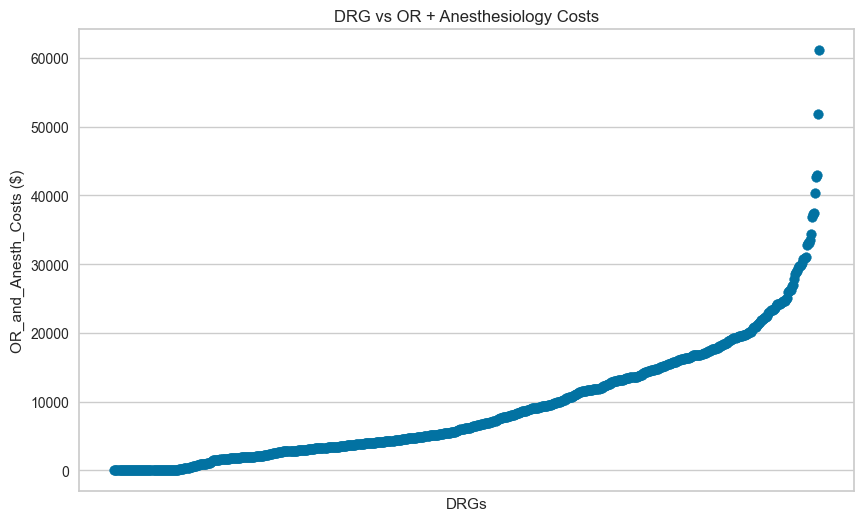

In [30]:
# Plotting the data for inspection
# Create scatter plot

crosstab1_sorted = crosstab1.sort_values(by='PCC_OR_and_Anesth_Costs')

plt.figure(figsize=(10, 6))
plt.scatter(crosstab1_sorted.index.get_level_values(0), crosstab1_sorted['PCC_OR_and_Anesth_Costs'])
plt.xlabel('DRGs')
plt.ylabel('OR_and_Anesth_Costs ($)')
plt.title('DRG vs OR + Anesthesiology Costs')
# Remove x-axis tick marks and labels
plt.xticks([])
plt.show()

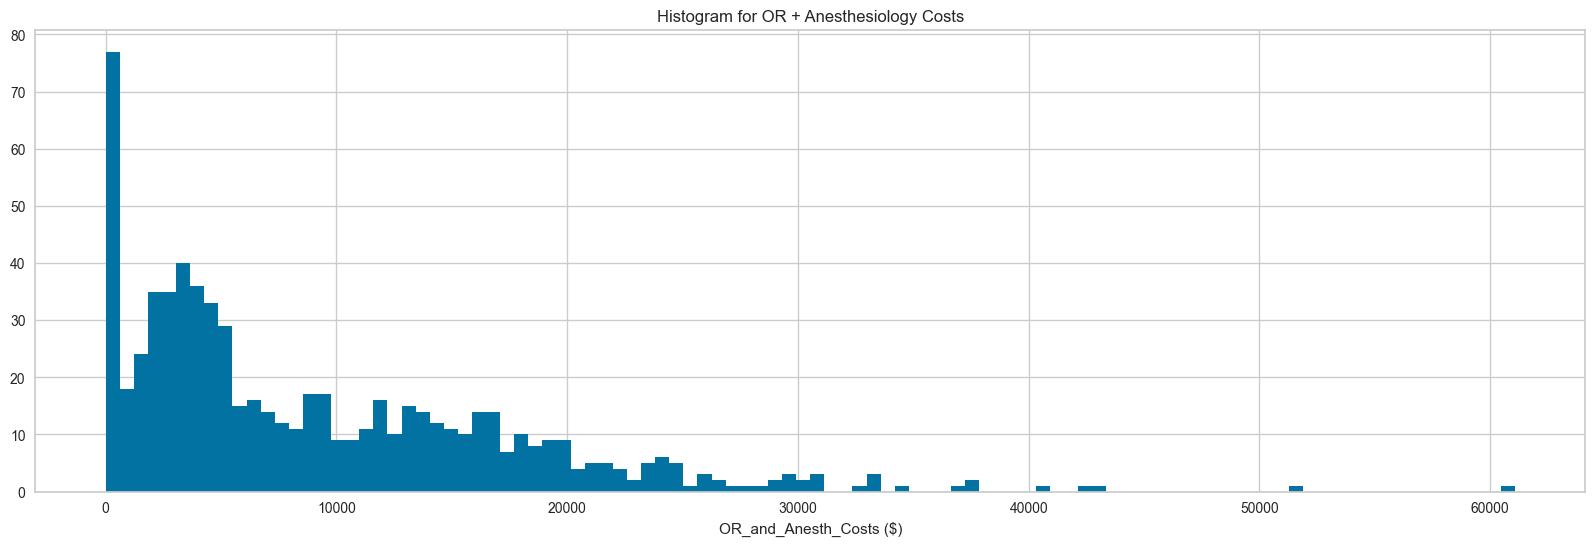

In [31]:
plt.figure(figsize=(20, 6))
crosstab1['PCC_OR_and_Anesth_Costs'].hist(bins=100)
plt.xlabel('OR_and_Anesth_Costs ($)')
plt.title('Histogram for OR + Anesthesiology Costs')
plt.show()

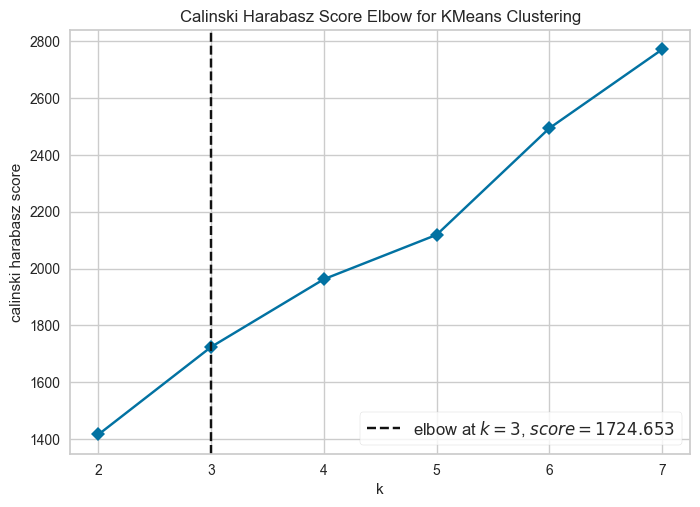

Optimal number of clusters (k) based on calinski harabasz score: 3


In [37]:
# Calinski Harabasz

# Scale the data
scaler = StandardScaler()
X = crosstab1[['PCC_OR_and_Anesth_Costs']]
X_scaled = scaler.fit_transform(X)

# Create KMeans instance for different numbers of clusters
model = KMeans(random_state=21)

# Use yellowbrick to visualize the Calinski-Harabasz score for different number of clusters
visualizer = KElbowVisualizer(model, k=(2, 8), metric='calinski_harabasz', timings=False)

# Fit the visualizer to the scaled data
visualizer.fit(X_scaled)

# Visualize the Calinski-Harabasz score
visualizer.show()

# Print optimal number of clusters (k)
optimal_k = visualizer.elbow_value_
print("Optimal number of clusters (k) based on calinski harabasz score:", optimal_k)

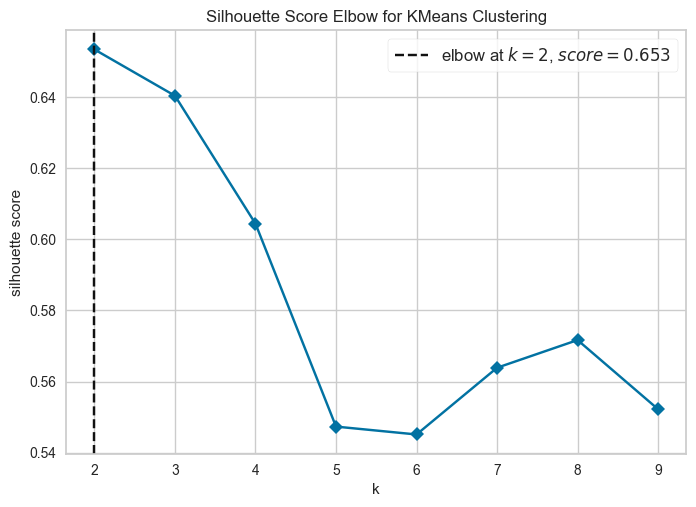

Optimal number of clusters (k) based on silhouette score: 2


In [57]:
# Silhouette Score: measures how similar an object is to its own cluster compared to other clusters. We plot the silhouette scores for different numbers of clusters and choose the number of clusters that maximizes the silhouette score

# Create KMeans instance for different numbers of clusters
model = KMeans(random_state=21)

# Use yellowbrick to visualize the silhouette score for different numbers of clusters
visualizer = KElbowVisualizer(model, k=(2, 10), metric='silhouette', timings=False)

# Fit the visualizer to the scaled data
visualizer.fit(X_scaled)

# Visualize the silhouette score
visualizer.show()

# Obtain the optimal number of clusters (k)
optimal_k = visualizer.elbow_value_
print("Optimal number of clusters (k) based on silhouette score:", optimal_k)

In [378]:
# Questions:
# Do I need to scale?
# Do I need to sort the values?

Now consider your solution with only 3 clusters. Can you graph your costs and somehow color code your cost points to reflect the 3 clusters? You can use any tool for graphing your clusters. 

In [58]:
# Cluster Analysis with k=3
optimal_k = 3

# Create KMeans instance with optimal number of clusters (optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=21)

# Fit KMeans clustering model to the scaled data
kmeans.fit(X_scaled)

# Add a new column to your DataFrame with assigned cluster labels
crosstab1['Cluster_Labels'] = kmeans.labels_

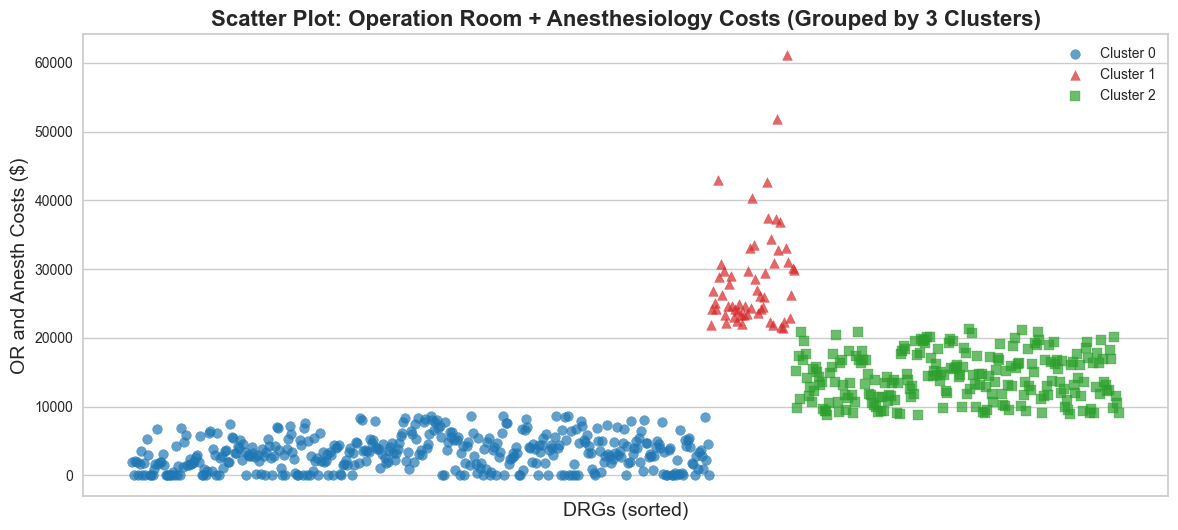

In [112]:
# Visualize the grouping by color
plt.figure(figsize=(14, 6))

# Define marker styles for each cluster
marker_styles = ['o', '^', 's']
    
# Define colors for each cluster
color_map = plt.colormaps['tab10']
colors = [color_map(0), color_map(3), color_map(2)]

for label, marker_style, color in zip(range(optimal_k), marker_styles, colors):
    plt.scatter(crosstab1[crosstab1['Cluster_Labels'] == label].index.get_level_values(0),
                crosstab1[crosstab1['Cluster_Labels'] == label]['PCC_OR_and_Anesth_Costs'],
                label=f'Cluster {label}', alpha=0.7, marker=marker_style, color=color)

plt.xlabel('DRGs (sorted)', fontsize=14)
plt.ylabel('OR and Anesth Costs ($)', fontsize=14)
plt.title(f'Scatter Plot: Operation Room + Anesthesiology Costs (Grouped by {optimal_k} Clusters)', fontsize=16, fontweight='bold')
plt.legend()
# Remove x-axis tick marks and labels
plt.xticks([])
plt.show()

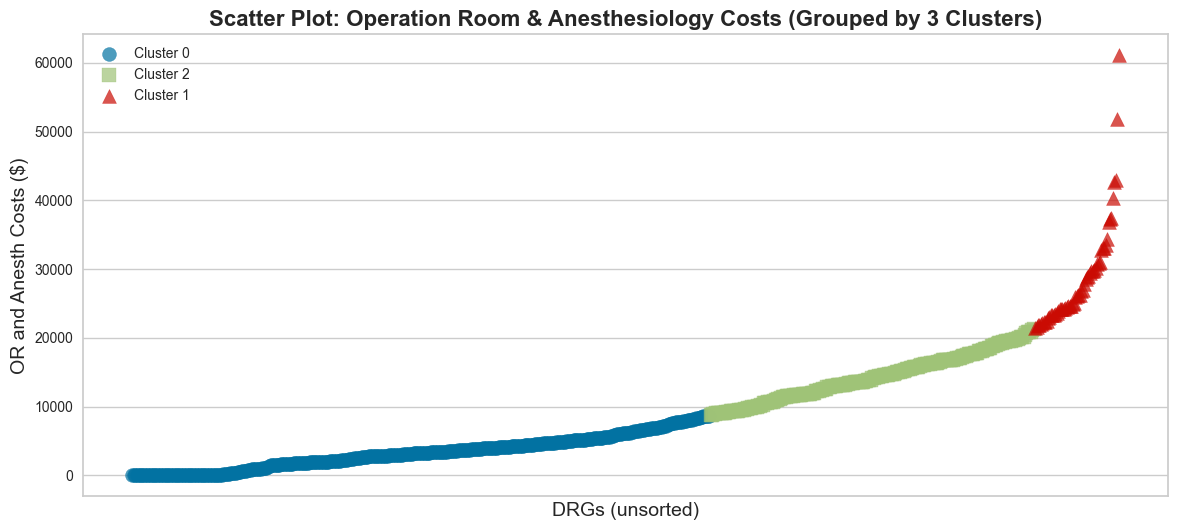

In [113]:
# Sort crosstab for better visualization
final_sorted = crosstab1.sort_values(by='PCC_OR_and_Anesth_Costs')

# Define the order in which we want the clusters to appear in the legend
cluster_order = [0, 2, 1] 

# Define the order of legend labels
#legend_labels = [f'Cluster {label}' for label in sorted(cluster_order)]

# Define marker styles for each cluster
marker_styles = ['o', 's', '^']

# Visualize the grouping by color
plt.figure(figsize=(14, 6))
for label, marker_style in zip(cluster_order, marker_styles):
    plt.scatter(final_sorted[final_sorted['Cluster_Labels'] == label].index.get_level_values(0),
                final_sorted[final_sorted['Cluster_Labels'] == label]['PCC_OR_and_Anesth_Costs'],
                label=f'Cluster {label}', alpha=0.7, marker=marker_style, s=100)
plt.xlabel('DRGs (unsorted)', fontsize=14)
plt.ylabel('OR and Anesth Costs ($)', fontsize=14)
plt.title(f'Scatter Plot: Operation Room & Anesthesiology Costs (Grouped by {optimal_k} Clusters)', fontsize=16, fontweight='bold')
# Use the legend_labels to specify the order of legend labels
plt.legend()
#plt.legend(legend_labels)

# Remove x-axis tick marks and labels
plt.xticks([])
plt.show()

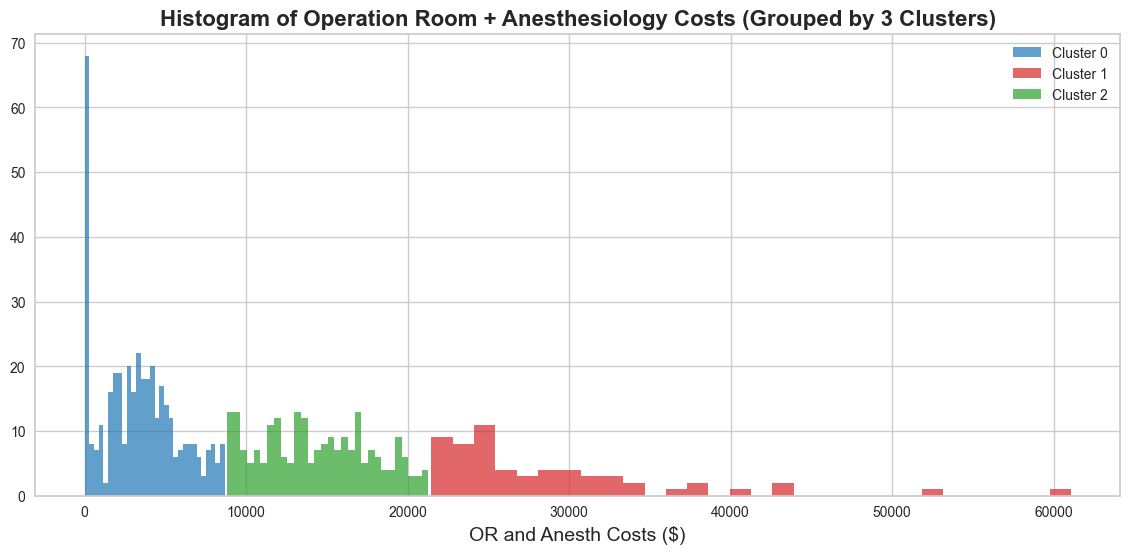

In [100]:
categories = sorted(crosstab1['Cluster_Labels'].unique())
num_categories = len(categories)
color_map = plt.colormaps['tab10']
colors = [color_map(0), color_map(3), color_map(2)]  # Blue, Green, Red

plt.figure(figsize=(14, 6))
# Iterate through categories, plot histogram for each category with different color
for i, category in enumerate(categories):
    data = crosstab1[crosstab1['Cluster_Labels'] == category]['PCC_OR_and_Anesth_Costs']
    plt.hist(data, bins=30, color=colors[i % 3], alpha=0.7, label=f'Cluster {category}')

plt.xlabel('OR and Anesth Costs ($)', fontsize=14)
plt.title('Histogram of Operation Room + Anesthesiology Costs (Grouped by 3 Clusters)', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

In [521]:
crosstab1[crosstab1['Cluster_Labels']==0]

,,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify),PCC_OR_and_Anesth_Costs,Cluster_Labels
DRG,MSDRG_DESC,,,,,,,,,,,,,,,,,,,,,
52,Spinal disorders & injuries w CC/MCC,0.0,0.0,0.0,0.0,0.00,1951.0,1047.500000,4019.8,0.0,8701.610000,...,919.080000,3963.645500,0.00,0.0,262.500,4878.598750,0.000000,0.0,2025.190000,0
53,Spinal disorders & injuries w/o CC/ MCC,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.0,0.0,4595.850000,...,0.000000,839.822500,0.00,0.0,0.000,4977.505000,0.000000,0.0,0.000000,0
56,Degenerative nervous system disorders w MCC,0.0,0.0,234.0,0.0,10082.43,1951.0,849.333333,0.0,0.0,3435.171154,...,748.176429,6125.283226,4221.26,0.0,213.000,2328.334400,3242.242000,0.0,2095.190833,0
57,Degenerative nervous system disorders w/o MCC,0.0,0.0,415.8,0.0,0.00,1899.0,980.325000,2288.8,0.0,3078.809109,...,478.503810,2380.893424,0.00,0.0,187.125,1968.694071,1743.641667,0.0,1921.584333,0
58,Multiple sclerosis & cerebellar ataxia w MCC,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.0,0.0,1257.040000,...,0.000000,371.520000,0.00,0.0,0.000,1128.000000,0.000000,0.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
951,Other factors influencing health status,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.0,0.0,2514.080000,...,1340.620000,642.697000,0.00,0.0,0.000,1941.926667,2961.000000,0.0,882.320000,0
964,Other multiple significant trauma w CC,0.0,0.0,0.0,0.0,0.00,0.0,883.000000,0.0,0.0,11534.477353,...,807.921000,2253.540000,0.00,0.0,205.000,5053.702703,935.000000,0.0,8562.218857,0
965,Other multiple significant trauma w/o CC/MCC,0.0,0.0,0.0,0.0,0.00,0.0,284.500000,0.0,0.0,6718.922500,...,237.495000,1443.811429,0.00,0.0,0.000,5902.772353,387.750000,0.0,2203.235000,0


In [522]:
crosstab1[crosstab1['Cluster_Labels']==1]

,,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify),PCC_OR_and_Anesth_Costs,Cluster_Labels
DRG,MSDRG_DESC,,,,,,,,,,,,,,,,,,,,,
25,Craniotomy & endovascular intracranial procedures w MCC,0.00,0.0,0.000,0.0,0.000000,4126.840000,0.000000,545.0,0.0,10254.480152,...,2110.928235,4970.941912,4442.240,0.000000,194.000000,3279.719535,0.000000,0.0,21856.537651,1
28,Spinal procedures w MCC ..................,0.00,0.0,0.000,0.0,0.000000,0.000000,0.000000,140.0,0.0,10324.254000,...,2387.425000,6267.803333,0.000,0.000000,194.000000,7983.174000,0.000000,0.0,24159.528000,1
42,Periph/cranial nerve & other nerv syst proc w/o CC/MCC,0.00,0.0,0.000,0.0,0.000000,1899.000000,1215.000000,0.0,0.0,4334.320000,...,1202.323333,1133.525000,0.000,6133.440000,0.000000,1236.500000,0.000000,0.0,26782.965000,1
129,Major head & neck procedures w CC/ MCC or major device,0.00,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,427.913333,1447.831429,0.000,0.000000,0.000000,0.000000,0.000000,0.0,25095.217143,1
135,Sinus & mastoid procedures w CC/ MCC,0.00,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.0,0.0,5205.000000,...,353.350000,8602.855000,0.000,0.000000,0.000000,2413.640000,0.000000,0.0,24228.410000,1
215,Other heart assist system implant ......,0.00,0.0,0.000,0.0,12282.780000,14935.365000,0.000000,0.0,0.0,11859.490000,...,2637.013333,3693.003333,0.000,0.000000,0.000000,6311.420000,0.000000,0.0,43012.840000,1
216,Cardiac valve & oth maj cardiothoracic proc w card cath w MCC,0.00,0.0,0.000,0.0,13217.029091,22603.068333,0.000000,0.0,0.0,10751.442500,...,4047.989167,9528.278333,0.000,0.000000,196.000000,2608.345000,493.500000,0.0,28785.721250,1
217,Cardiac valve & oth maj cardiothoracic proc w card cath w CC,0.00,0.0,0.000,0.0,9861.595000,1706.250000,0.000000,0.0,0.0,6075.665000,...,2580.410000,7316.622500,0.000,0.000000,0.000000,3545.690000,705.000000,0.0,30720.272500,1
218,Cardiac valve & oth maj cardiothoracic proc w card cath w/o CC/MCC,0.00,0.0,0.000,0.0,9839.462500,62889.270000,0.000000,0.0,0.0,4158.545000,...,1485.575000,3371.017500,0.000,0.000000,0.000000,2266.225000,430.100000,0.0,26216.540833,1


In [523]:
crosstab1[crosstab1['Cluster_Labels']==2]

,,Angiocardiography,Audiology,Bacteriology and Microbiology,Birthing Center,Cardiac Catheterization Laboratory,Cardiology,Chemistry,Chemotherapy,Circumcision,CAT Scan,...,Med Supplies Charged to Patient,Drugs Charged to Patients,Renal Dialysis,ASC,Clinic,Emergency,Observation Beds (Distinct Part),Other Organ Acquisition (Specify),PCC_OR_and_Anesth_Costs,Cluster_Labels
DRG,MSDRG_DESC,,,,,,,,,,,,,,,,,,,,,
21,Intracranial vascular procedures w PDX hemorrhage w CC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,18462.436000,...,7085.536000,14013.122000,0.0,0.00,0.0,3263.788000,0.0,0.0,15172.697333,2
22,Intracranial vascular procedures w PDX hemorrhage w/o CC/MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,5650.630000,...,7261.395000,5793.075000,0.0,0.00,0.0,2984.330000,0.0,0.0,9857.045000,2
23,Cranio w major dev impl/acute complex CNS PDX w MCC or chemo implant,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,16825.415769,...,8392.076667,11467.082308,2613.3,0.00,0.0,5432.852400,0.0,0.0,17395.647803,2
24,Cranio w major dev impl/acute complex CNS PDX w/o MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,10460.321429,...,8761.326250,4812.456250,0.0,0.00,0.0,4317.347500,0.0,0.0,11151.287917,2
26,Craniotomy & endovascular intracranial procedures w CC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,7028.553684,...,3005.317407,3158.831852,0.0,0.00,0.0,4550.053333,0.0,0.0,20890.974074,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,Aftercare w/o CC/MCC,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,2347.740000,...,1011.548000,1108.586207,0.0,0.00,0.0,1819.866000,1198.5,0.0,9763.060000,2
955,Craniotomy for multiple significant trauma,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,23832.198889,...,4459.828750,11710.784444,0.0,0.00,0.0,13050.767778,0.0,0.0,20193.736250,2
963,Other multiple significant trauma w MCC,0.0,0.0,3245.9,0.0,0.0,1330.48,1806.0,0.0,0.0,18314.677778,...,1862.343846,7210.482632,0.0,0.00,0.0,7313.056111,0.0,0.0,11526.403571,2


In [524]:
#crosstab1.to_excel('cluster_analysis.xlsx')